In [1]:
import os
import wandb
import warnings
import datasets
import torch
import plotly.graph_objects as go
from collections import defaultdict
import matplotlib.pyplot as plt

from transformers import PreTrainedTokenizerFast, RobertaForSequenceClassification
from tqdm import tqdm

warnings.filterwarnings("ignore")

device = torch.device("mps")
dataset = datasets.load_from_disk(
    "/Users/henrywilliams/Documents/programming/python/ai/malbert-test/data/raw"
)
tokenizer = PreTrainedTokenizerFast.from_pretrained("../MalBERTa")


os.environ["WANDB_SILENT"] = "true"
os.environ["TQDM_DISABLE"] = "1"

N_SAMPLES = 1
FORWARD_SIZE = 256

models = {
    "base": {
        "base": "e96b8h5a",
        "pretrained": "e1tosi4k",
        "frozen": "t4o7wvla",
    },
    "ob": {
        "base": "swcod025",
        "pretrained": "xzlusbyu",
        "frozen": "aqzn99cx",
    },
    "pob": {
        "base": "wozkyaa6",
        "pretrained": "daf0h543",
        "frozen": "47y92682",
    },
}

In [2]:
def tokenize(model, sample, tokenizer):
    seq_len = model.config.max_position_embeddings - 2

    input = tokenizer(
        sample["text"],
        padding="max_length",
        max_length=seq_len,
        return_overflowing_tokens=True,
        truncation=True,
        return_special_tokens_mask=True,
        return_tensors="pt",
    )

    return input


def get_model(id):
    api = wandb.Api()
    artifact = api.artifact(
        f"henry-williams/opcode-malberta/model-{id}:v1", type="model"
    )
    artifact_dir = artifact.download()
    return RobertaForSequenceClassification.from_pretrained(artifact_dir)


In [3]:
def linear_CKA(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    def center_gram(K: torch.Tensor) -> torch.Tensor:
        n = K.size(0)
        H = torch.eye(n, device=K.device) - torch.ones(n, n, device=K.device) / n
        return H @ K @ H

    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)

    K = X @ X.T
    L = Y @ Y.T

    Kc = center_gram(K)
    Lc = center_gram(L)

    hsic = (Kc * Lc).sum()
    norm_x = (Kc * Kc).sum().sqrt()
    norm_y = (Lc * Lc).sum().sqrt()

    return hsic / (norm_x * norm_y + 1e-12)

In [4]:
def get_hook(name, act_dict):
    def right_hook(module, input, output):
        if isinstance(output, torch.Tensor):
            act_dict[name].append(output)

    return right_hook


def get_cka(l_id, r_id):
    l_model = get_model(l_id).to("mps")
    r_model = get_model(r_id).to("mps")

    left_activations = defaultdict(list)
    right_activations = defaultdict(list)

    for (name_b, module_b), (name_p, module_p) in zip(
        l_model.named_modules(), r_model.named_modules()
    ):
        module_b.register_forward_hook(get_hook(name_b, left_activations))
        module_p.register_forward_hook(get_hook(name_p, right_activations))

    sims = []

    for a, sample in enumerate(dataset["test"].shuffle().select(range(N_SAMPLES))):
        torch.mps.empty_cache()
        input = tokenize(l_model, sample, tokenizer)

        with torch.no_grad():
            l_model(
                input_ids=input["input_ids"][:FORWARD_SIZE].to("mps"),
                attention_mask=input["attention_mask"][:FORWARD_SIZE].to("mps"),
            )

            r_model(
                input_ids=input["input_ids"][:FORWARD_SIZE].to("mps"),
                attention_mask=input["attention_mask"][:FORWARD_SIZE].to("mps"),
            )

        sim_matrix = torch.zeros((len(left_activations), len(left_activations)))
        loop = tqdm(
            total=len(left_activations) ** 2,
            desc=f"{a + 1}/{N_SAMPLES} Computing RSA w/ CKA",
            leave=True,
        )

        for i, (k_b, v_b) in enumerate(right_activations.items()):
            base_act = v_b[-1].reshape(v_b[-1].shape[0], -1)

            for j, (k_p, v_p) in enumerate(right_activations.items()):
                pretrained_act = v_p[-1].reshape(v_p[-1].shape[0], -1)
                sim_matrix[i, j] = linear_CKA(
                    base_act.detach(), pretrained_act.detach()
                )
                loop.update(1)

        sims.append(sim_matrix)

    sim_matrix = torch.stack(sims).mean(dim=0)
    return sim_matrix, left_activations, right_activations


# sim_matrix, left_activations, right_activations = get_cka(
#     models["base"]["pretrained"], models["base"]["frozen"]
# )

In [5]:
# import numpy as np


# def custom_hover_text(x, y, value):
#     return f"CKA: {value:.3}<br>Left: {list(left_activations.keys())[x]}<br>Right: {list(right_activations.keys())[y]}<br>({x}, {y})"


# nrows, ncols = sim_matrix.shape
# customdata = np.empty((nrows, ncols), dtype=object)

# for i in range(nrows):
#     for j in range(ncols):
#         customdata[i, j] = custom_hover_text(i, j, sim_matrix[i, j])

# fig = go.Figure(
#     data=go.Heatmap(
#         z=sim_matrix,
#         colorscale="Viridis",
#         customdata=customdata,
#         hovertemplate="%{customdata}<extra></extra>",
#         showscale=True,
#     ),
# )

# fig.update_layout(
#     xaxis=dict(showticklabels=False),
#     yaxis=dict(showticklabels=False, scaleanchor="x", scaleratio=1),
#     plot_bgcolor="rgba(255,255,255,255)",
#     paper_bgcolor="rgba(255,255,255,255)",
#     margin=dict(t=30, b=10, l=10, r=10),
#     title=dict(
#         text="RSA of Base and Pretrained",
#         xref="paper",
#         yref="container",
#         yanchor="top",
#         x=0.5,
#         automargin=True,
#         pad=dict(t=5),
#     ),
# )

# fig.show()

In [6]:
N_SAMPLES = 5

sim, _, _ = get_cka(models["base"]["pretrained"], models["base"]["frozen"])

wandb: Downloading large artifact model-e1tosi4k:v1, 87.83MB. 7 files... 
wandb:   7 of 7 files downloaded.  
Done. 0:0:0.8 (103.5MB/s)
wandb: Downloading large artifact model-t4o7wvla:v1, 87.83MB. 7 files... 
wandb:   7 of 7 files downloaded.  
Done. 0:0:0.9 (93.1MB/s)
5/5 Computing RSA w/ CKA: 100%|██████████| 11664/11664 [00:34<00:00, 334.13it/s]


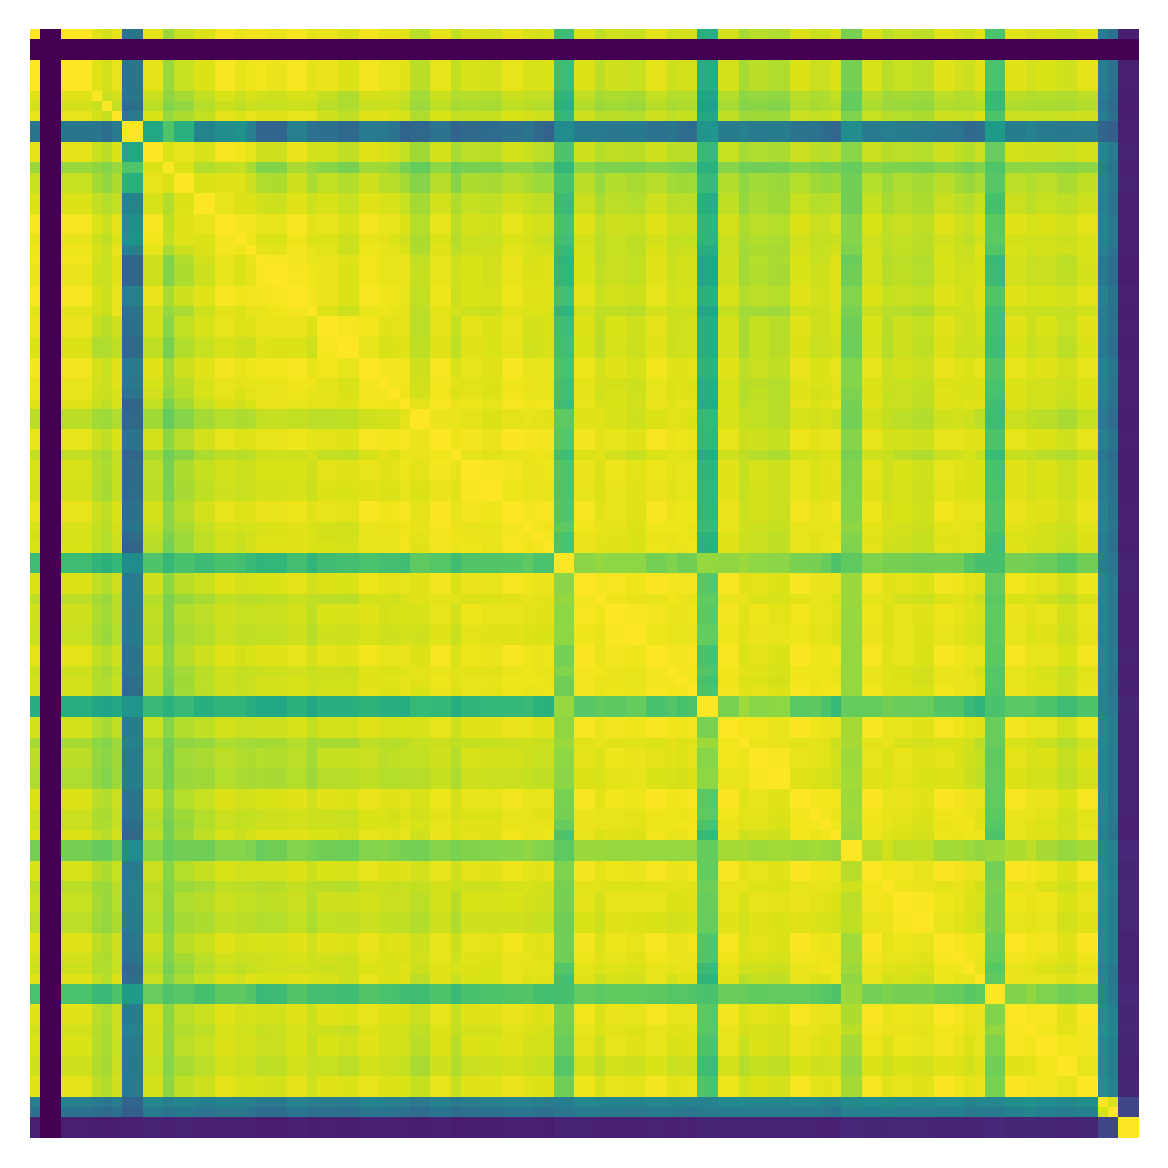

In [7]:
plt.figure(dpi=300)
plt.imshow(sim)
plt.axis("off")
plt.savefig("../../../writing/thesis/assets/rsa-cka-base-pretrained-frozen.png")
plt.show()